In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/wine-quality-dataset")

print("Path to dataset files:", path)

c:\Users\yamaw\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\yamaw\.cache\kagglehub\datasets\yasserh\wine-quality-dataset\versions\1


In [2]:
import os
import pandas as pd

# ダウンロードしたフォルダの中にあるCSVファイルを読み込む
csv_file = os.path.join(path, "WineQT.csv")
df = pd.read_csv(csv_file)

df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [3]:
# ID列を削除
df = df.drop("Id", axis=1)

# 列名を日本語に書き換える
df.columns = [
    "固定酸", "揮発酸", "クエン酸", "残糖", "塩化物",
    "遊離二酸化硫黄", "総二酸化硫黄", "密度", "pH",
    "硫酸塩", "アルコール", "品質"
]

df.head()

,固定酸,揮発酸,クエン酸,残糖,塩化物,遊離二酸化硫黄,総二酸化硫黄,密度,pH,硫酸塩,アルコール,品質
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
固定酸,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
揮発酸,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
クエン酸,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
残糖,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
塩化物,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
遊離二酸化硫黄,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
総二酸化硫黄,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
密度,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
硫酸塩,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


In [5]:
# 品質7以上を1、それ以外を0に変換
df["品質"] = df["品質"].apply(lambda x: 1 if x >= 7 else 0)

# 結果を確認
print(df["品質"].value_counts())

品質
0    984
1    159
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split

# 特徴量と正解に分ける
X = df.drop("品質", axis=1)
y = df["品質"]

# データを分割（学習用80%、テスト用20%に分ける）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 確認
print(f"学習用データの数：{len(X_train)}")
print(f"テスト用データの数：{len(X_test)}")

学習用データの数：914
テスト用データの数：229


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# モデルの作成
model = RandomForestClassifier(random_state=42)

# 学習開始
model.fit(X_train, y_train)

# テスト
y_pred = model.predict(X_test)

# 正解率の確認
accuracy = accuracy_score(y_test, y_pred)
print(f"モデルの正解率：{accuracy:.2%}")

モデルの正解率：91.70%


In [8]:
from sklearn.metrics import classification_report

# 適合率、再現率、F1スコアを表示
report_dict = classification_report(y_test, y_pred, target_names=["普通（0）", "当たり(1)"], output_dict=True)

report_df = pd.DataFrame(report_dict).T

display(report_df.round(3))

,precision,recall,f1-score,support
普通（0）,0.942,0.965,0.953,201.000
当たり(1),0.696,0.571,0.627,28.000
accuracy,0.917,0.917,0.917,0.917
macro avg,0.819,0.768,0.790,229.000
weighted avg,0.912,0.917,0.913,229.000


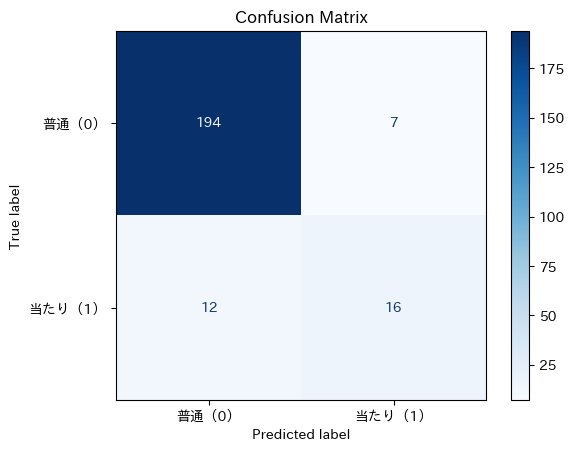

In [9]:
import matplotlib.pyplot as plt
import japanize_matplotlib
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 混同行列のデータを計算
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["普通（0）", "当たり（1）"])
disp.plot(cmap=plt.cm.Blues)

plt.title("Confusion Matrix")
plt.show()

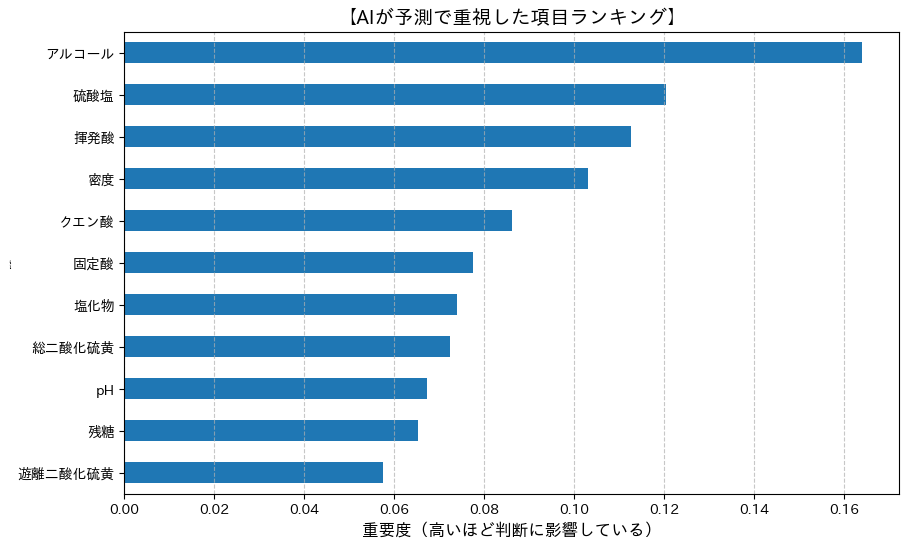

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# model(ランダムフォレスト)から重要度を取り出す
importances = pd.Series(model.feature_importances_, index=X_train.columns)

# グラフで見やすいように並び替え
importances_sorted = importances.sort_values(ascending=True)

# 描画
plt.figure(figsize=(10, 6))
importances_sorted.plot(kind="barh")
plt.title("【AIが予測で重視した項目ランキング】", fontsize=14)
plt.xlabel("重要度（高いほど判断に影響している）", fontsize=12)
plt.ylabel("データの項目名", fontsize=0.7)

plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

In [11]:
# 重要度が低かった項目を削った新しいデータを作る
X_train_reduced = X_train.drop(["遊離二酸化硫黄", "残糖"], axis=1)
X_test_reduced = X_test.drop(["遊離二酸化硫黄", "残糖"], axis=1)

# 削ったデータでもう一度AIに学習させる
model2 = RandomForestClassifier(random_state=42)
model2.fit(X_train_reduced, y_train)

# 正解率を表示してみる
y_pred2 = model2.predict(X_test_reduced)
from sklearn.metrics import accuracy_score
print(f"データを削除した後の正解率：{accuracy_score(y_test, y_pred2):.2%}")

データを削除した後の正解率：91.70%


In [12]:
# 木の深さを「5」に制限した新しいAIを作成する
model3 = RandomForestClassifier(max_depth=5, random_state=42)

# 学習
model3.fit(X_train_reduced, y_train)

# 予測とスコア表示
y_pred3 = model3.predict(X_test_reduced)
print(f"木の深さを5に制限した時の正解率：{accuracy_score(y_test, y_pred3):.2%}")

木の深さを5に制限した時の正解率：90.39%


In [13]:
# 木の数を500ポンに増やし、深さは自由にしてみる
model4 = RandomForestClassifier(n_estimators=500, random_state=42)

# 学習
model4.fit(X_train_reduced, y_train)

# 予測とスコア表示
y_pred4 = model4.predict(X_test_reduced)
print(f"木の数を500ポンにしたときの正解率：{accuracy_score(y_test, y_pred4):.2%}")

木の数を500ポンにしたときの正解率：92.58%


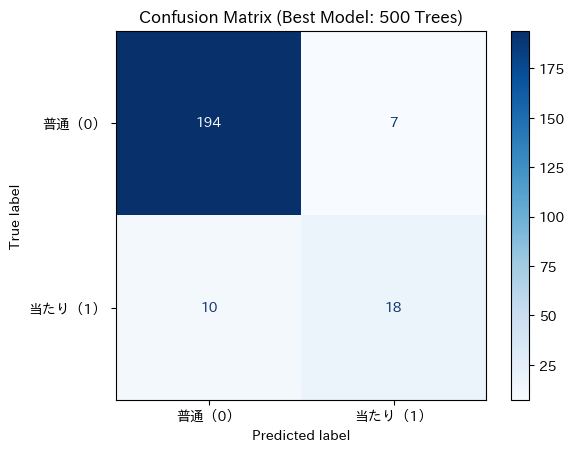

In [14]:
import matplotlib.pyplot as plt
import japanize_matplotlib
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# model4の結果を混同行列で確認
cm4 = confusion_matrix(y_test, y_pred4)
disp4 = ConfusionMatrixDisplay(confusion_matrix=cm4, display_labels=["普通（0）", "当たり（1）"])

disp4.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Best Model: 500 Trees)")
plt.show()

In [15]:
from sklearn.preprocessing import MinMaxScaler

# スケーラー（正規化の道具）を準備
scaler = MinMaxScaler()

# X（特徴量）を正規化する
X_train_scaled = scaler.fit_transform(X_train_reduced)
X_test_scaled = scaler.transform(X_test_reduced)

# 500本の木で再学習
model_scaled = RandomForestClassifier(n_estimators=500, random_state=42)
model_scaled.fit(X_train_scaled, y_train)

# 予測とスコア表示
y_pred_scaled = model_scaled.predict(X_test_scaled)
print(f"正規化+500本の木の正解率：{accuracy_score(y_test, y_pred_scaled):.2%}")


正規化+500本の木の正解率：92.58%


In [16]:
! pip install Lightgbm


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score

# LightGBM専用のデータ形式に変換
# 正規化したデータ（X_train_scaled）を使う
train_data = lgb.Dataset(X_train_scaled, label=y_train)

# AIの設定
params = {
    "objevtive": "binary",
    "metric": "binary_logloss",
    "verbosity": -1,
    "boosting_type": "gbdt",
    "random_state": 42
}

# 学習
lgb_model = lgb.train(params, train_data, num_boost_round=100)

# テストデータで予測
# 0.5以上を「当たり（1）」とする
y_pred_lgb_prob = lgb_model.predict(X_test_scaled)
y_pred_lgb = [1 if p >= 0.5 else 0 for p in y_pred_lgb_prob]

# 正解率の表示
print(f"LightGBMの正解率：{accuracy_score(y_test, y_pred_lgb):.2%}")

LightGBMの正解率：90.83%


In [18]:
#元のデータをコピーして新しいデータセットを作成する
X_train_new = X_train_reduced.copy()
X_test_new = X_test_reduced.copy()

# 3つの新しいヒントを追加
X_train_new["アルコール×揮発酸"] = X_train_new["アルコール"] * X_train_new["揮発酸"]
X_test_new["アルコール×揮発酸"] = X_test_new["アルコール"] * X_test_new["揮発酸"]

X_train_new["アルコール×密度"] = X_train["アルコール"] * X_train_new["密度"]
X_test_new["アルコール×密度"] = X_test["アルコール"] * X_test_new["密度"]

X_train_new["アルコール×クエン酸"] = X_train["アルコール"] * X_train_new["クエン酸"]
X_test_new["アルコール×クエン酸"] = X_test["アルコール"] * X_test_new["クエン酸"]

# 500本の木でが学習
model5 = RandomForestClassifier(n_estimators=500, random_state=42)
model5.fit(X_train_new, y_train)

# 予測と結果表示
y_pred5 = model5.predict(X_test_new)
print(f"ヒント追加後の正解率：{accuracy_score(y_test, y_pred5):.2%}")

ヒント追加後の正解率：93.89%


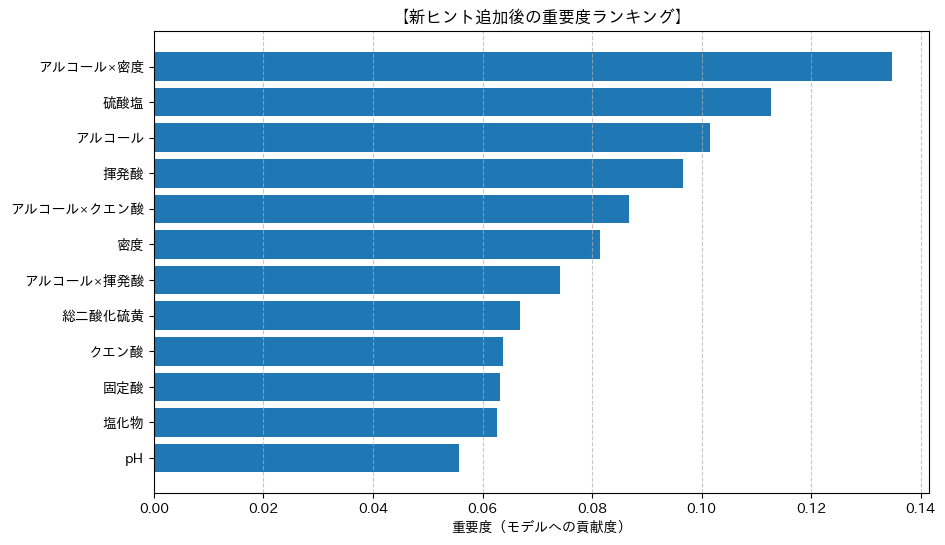

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# 重要度を取り出して表にする
importances = model5.feature_importances_
feature_names = X_train_new.columns
df_imp = pd.DataFrame({"項目": feature_names, "重要度": importances})
df_imp = df_imp.sort_values("重要度", ascending=True)

# グラフを表示
plt.figure(figsize=(10, 6))
plt.barh(df_imp["項目"], df_imp["重要度"])
plt.title("【新ヒント追加後の重要度ランキング】")
plt.xlabel("重要度（モデルへの貢献度）")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

In [20]:
import pandas as pd
from sklearn.metrics import classification_report

# model5で予測
y_pred5 = model5.predict(X_test_new)

report_dict = classification_report(y_test, y_pred5, target_names=["普通（0）", "当たり（1）"], output_dict=True)
report_df = pd.DataFrame(report_dict).T

display(report_df.round(3))

,precision,recall,f1-score,support
普通（0）,0.961,0.970,0.965,201.000
当たり（1）,0.769,0.714,0.741,28.000
accuracy,0.939,0.939,0.939,0.939
macro avg,0.865,0.842,0.853,229.000
weighted avg,0.937,0.939,0.938,229.000


In [21]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "max_features": ["sqrt", "log2"]
}

# グリッドサーチの設定
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# 最適な設定の探索を開始
grid_search.fit(X_train_new, y_train)

# 結果の表示
print(f"【最高の設定】: {grid_search.best_params_}")
print(f"【交差検証での最高正解率】: {grid_search.best_score_:.2%}")

【最高の設定】: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 300}
【交差検証での最高正解率】: 89.71%


In [22]:
# グリッドサーチで見つけた「最高の設定」のモデルを取り出す
best_model = grid_search.best_estimator_

# 予測してみる
y_pred_best = best_model.predict(X_test_new)

# 結果の表示
from sklearn.metrics import accuracy_score
print(f"【最高設定モデルの正解率】: {accuracy_score(y_test, y_pred_best):.2%}")

report_best = classification_report(y_test, y_pred_best, target_names=["普通（0）", "当たり（1）"], output_dict=True)
display(pd.DataFrame(report_best).T.round(3))

【最高設定モデルの正解率】: 93.45%


,precision,recall,f1-score,support
普通（0）,0.956,0.970,0.963,201.000
当たり（1）,0.760,0.679,0.717,28.000
accuracy,0.934,0.934,0.934,0.934
macro avg,0.858,0.824,0.840,229.000
weighted avg,0.932,0.934,0.933,229.000


In [23]:
from xgboost import XGBClassifier

# XGBoostのモデルを作成
model_xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

# 学習
model_xgb.fit(X_train_new, y_train)

y_pred_xgb = model_xgb.predict(X_test_new)

print(f"【XGBoostの正解率】: {accuracy_score(y_test, y_pred_xgb):.2%}")

xgb_report = classification_report(y_test, y_pred_xgb, target_names=["普通（0）", "当たり（1）"], output_dict=True)
display(pd.DataFrame(xgb_report).T.round(3))

【XGBoostの正解率】: 91.70%


,precision,recall,f1-score,support
普通（0）,0.960,0.945,0.952,201.000
当たり（1）,0.645,0.714,0.678,28.000
accuracy,0.917,0.917,0.917,0.917
macro avg,0.802,0.830,0.815,229.000
weighted avg,0.921,0.917,0.919,229.000
